In [47]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.metrics import (

    silhouette_score,

    calinski_harabasz_score,

    davies_bouldin_score
)

import joblib

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

In [48]:
df = pd.read_csv("Mall_Customers.csv")

In [49]:
df.head().style.background_gradient(cmap='viridis')

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [50]:
df.tail().style.background_gradient(cmap='viridis')

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [51]:
print(df.shape)

(200, 5)


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


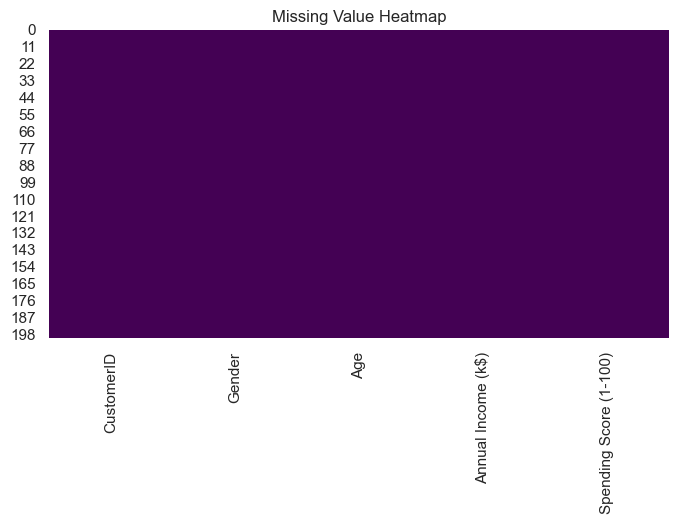

In [54]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.drop_duplicates(inplace=True)

Distribution of Age

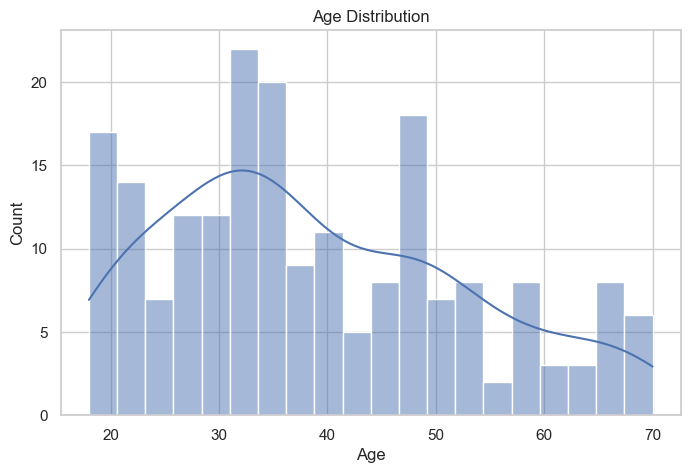

In [57]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

Distribution of Annual Income

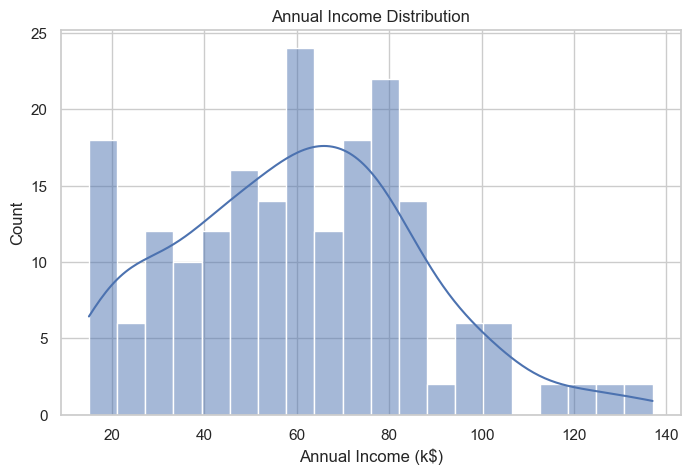

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Annual Income (k$)"],
    bins=20,
    kde=True
)

plt.title("Annual Income Distribution")

plt.show()

Spending Score Distribution

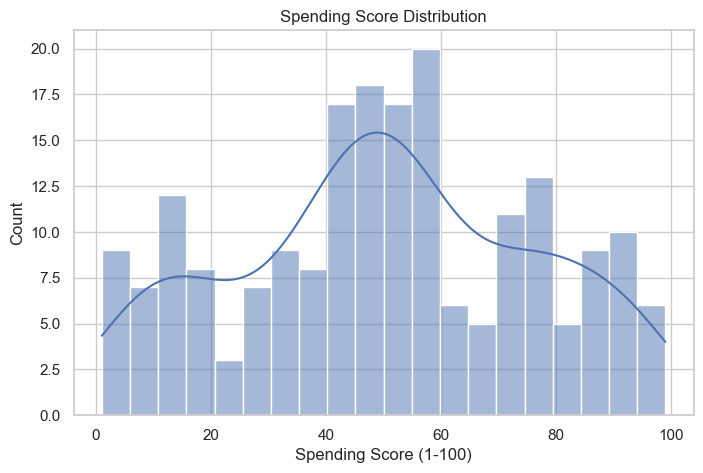

In [59]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Spending Score (1-100)"],
    bins=20,
    kde=True
)

plt.title("Spending Score Distribution")

plt.show()

Gender Distribution

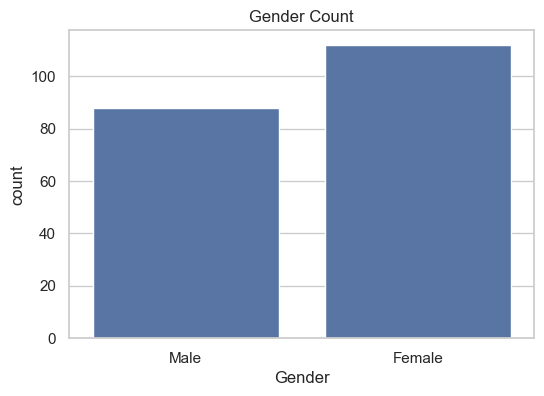

In [60]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Gender Count")

plt.show()

Age Boxplot

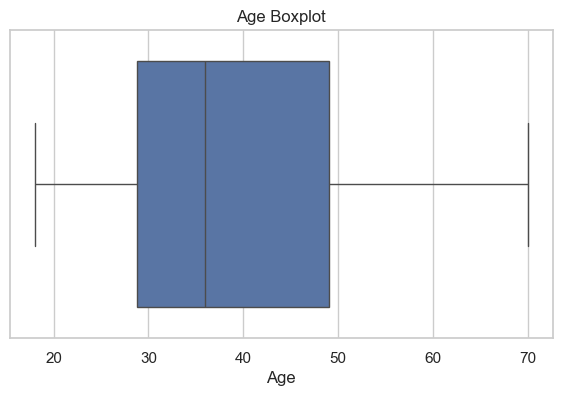

In [61]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x=df["Age"]
)

plt.title("Age Boxplot")

plt.show()

Income Boxplot

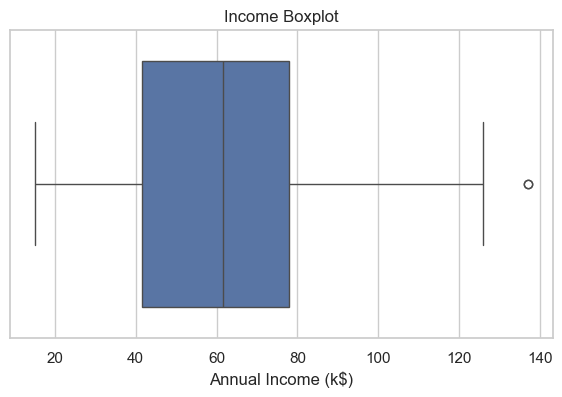

In [62]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x=df["Annual Income (k$)"]
)

plt.title("Income Boxplot")

plt.show()

Spending Score Boxplot

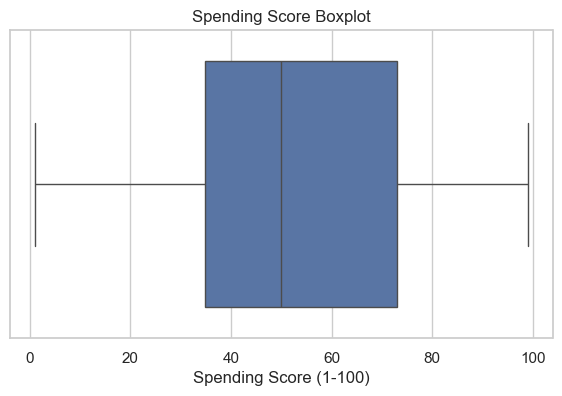

In [63]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x=df["Spending Score (1-100)"]
)

plt.title("Spending Score Boxplot")

plt.show()

Correlation Heatmap

Before computing correlations, encode the categorical Gender column.

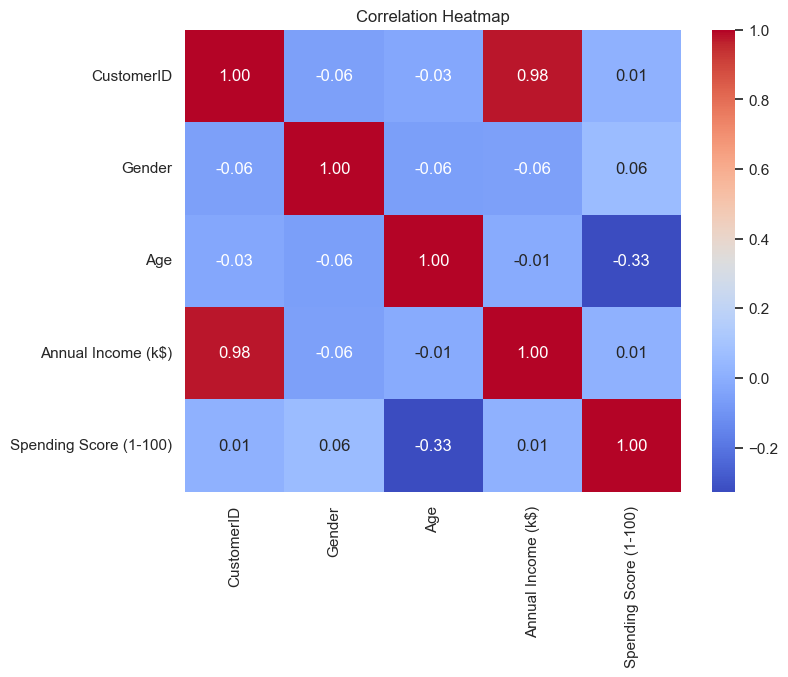

In [64]:
df_corr = df.copy()

df_corr["Gender"] = df_corr["Gender"].map({
    "Male": 0,
    "Female": 1
})

plt.figure(figsize=(8,6))

sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Feature Encoding

The Gender column is categorical. Since K-Means only works with numerical data, we need to encode it.

In [65]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

Encode Gender

In [66]:
df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1
})

In [67]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


Pairplot

Pairplots help visualize relationships among numerical variables.

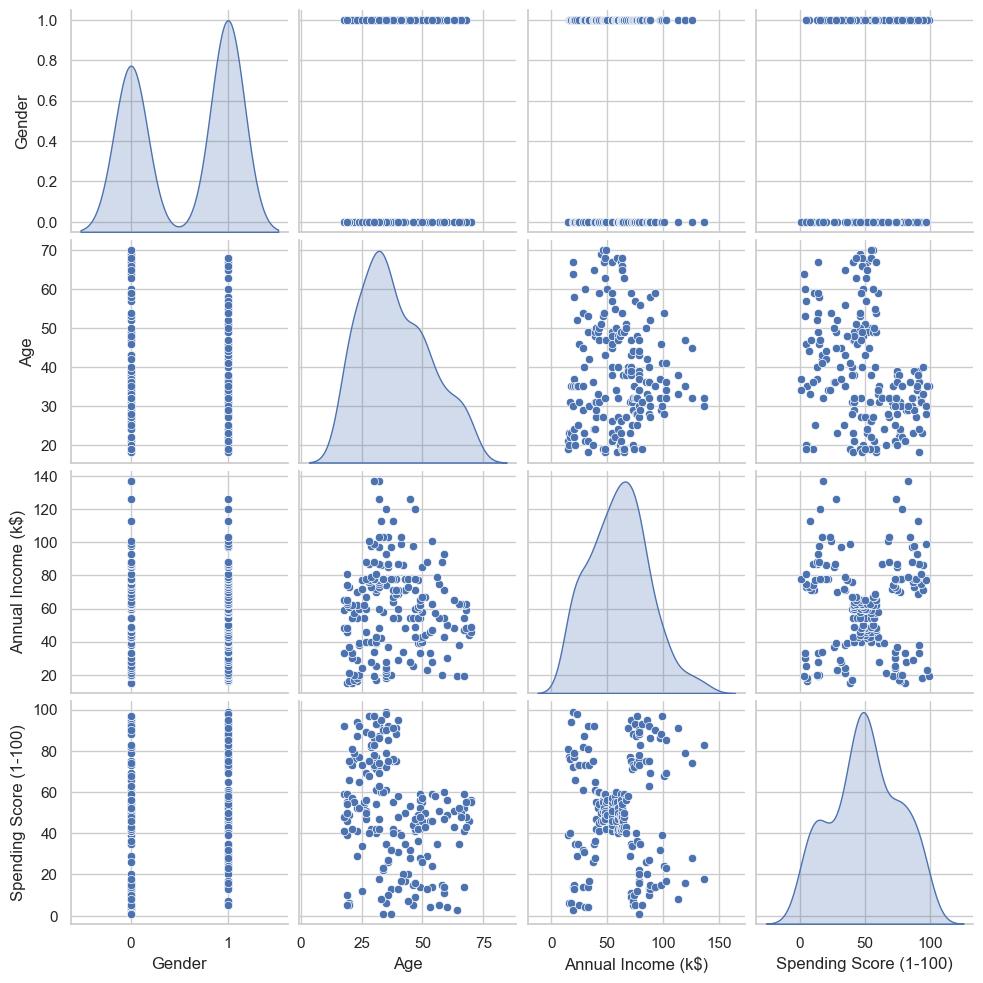

In [68]:
sns.pairplot(
    df.drop("CustomerID", axis=1),
    diag_kind="kde"
)

plt.show()

Feature Selection

CustomerID is only an identifier and should not be used for clustering.

In [69]:
X = df.drop("CustomerID", axis=1)

In [70]:
X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


Feature Scaling

Why Scale the Features?

K-Means relies on Euclidean distance. 
If features have different scales, variables with larger values dominate the clustering process.
We use StandardScaler to standardize the features.

In [71]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Convert Back to DataFrame

In [72]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980


Check Means

In [73]:
X_scaled.mean()

Gender                   -7.549517e-17
Age                      -1.021405e-16
Annual Income (k$)       -2.131628e-16
Spending Score (1-100)   -1.465494e-16
dtype: float64

Check Standard Deviations

In [74]:
X_scaled.std()

Gender                    1.002509
Age                       1.002509
Annual Income (k$)        1.002509
Spending Score (1-100)    1.002509
dtype: float64

Choosing the Optimal Number of Clusters

One of the most important steps in K-Means is selecting the appropriate value of K.

We begin with the Elbow Method.

Elbow method

In [75]:
wcss = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

Plot Elbow Curve

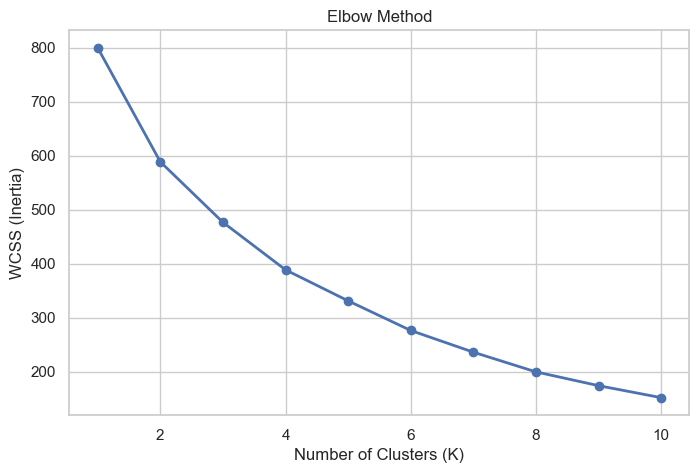

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS (Inertia)")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

Silhouette Analysis

The Silhouette Score measures how well-separated the clusters are.

Higher values indicate better clustering.

In [77]:
silhouette_scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

Plot Silhouette Scores

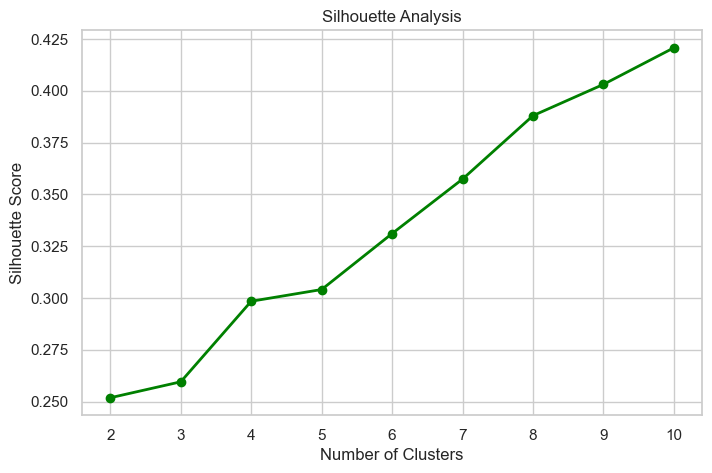

In [78]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o",
    linewidth=2,
    color="green"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

Best Silhouette Scores

In [79]:
best_k = np.argmax(silhouette_scores) + 2

print("Best K:", best_k)

Best K: 10


Train the Final K-Means Model

In [80]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

Add Cluster Labels to the Dataset

In [81]:
df["Cluster"] = clusters

In [82]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,0,19,15,39,3
1,2,0,21,15,81,3
2,3,1,20,16,6,3
3,4,1,23,16,77,3
4,5,1,31,17,40,3


In [83]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
195,196,1,35,120,79,0
196,197,1,45,126,28,1
197,198,0,32,126,74,0
198,199,0,32,137,18,1
199,200,0,30,137,83,0


Number of Customers in Each Cluster

In [84]:
df["Cluster"].value_counts().sort_index()

Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64

Visualize Cluster Sizes

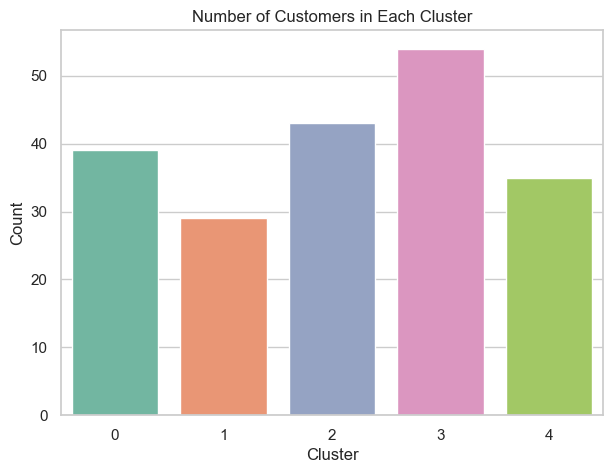

In [85]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Cluster",
    palette="Set2"
)

plt.title("Number of Customers in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Count")

plt.show()

PCA for Cluster Visualization

Although K-Means can use multiple features, it is difficult to visualize clusters beyond two or three dimensions.

Principal Component Analysis (PCA) reduces the feature space to two principal components while preserving most of the variance.

Apply PCA

In [86]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

Create a DataFrame for Visualization

In [87]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

In [88]:
pca_df.head()

,PC1,PC2,Cluster
0,-0.406383,-0.520714,3
1,-1.427673,-0.367310,3
2,0.050761,-1.894068,3
3,-1.694513,-1.631908,3
4,-0.313108,-1.810483,3


Scatter Plot of Clusters

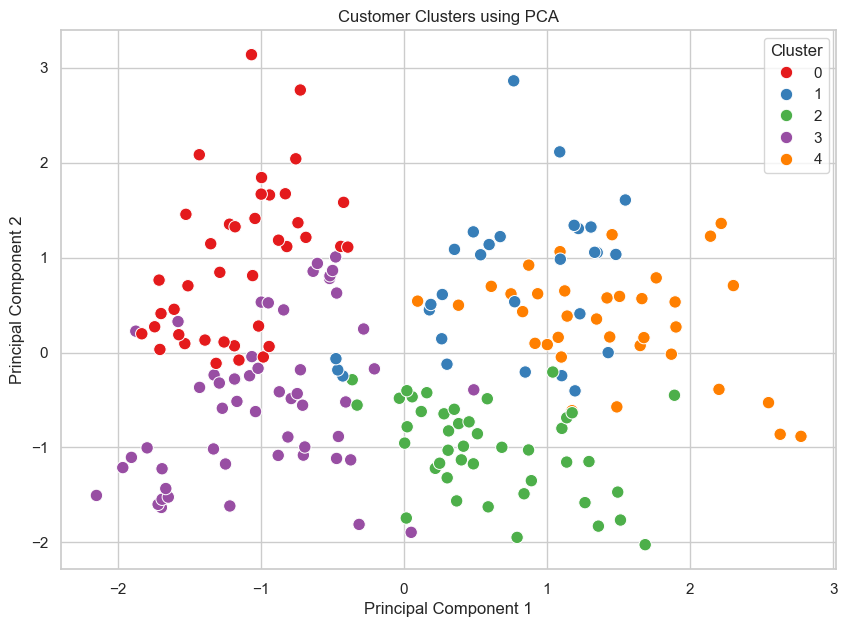

In [89]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Customer Clusters using PCA")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

Visualizing Cluster Centroids

Centroids in Scaled Feature Space

In [90]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)

centroids

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-0.043390,-0.441917,0.991583,1.239503
1,-0.016672,-0.169889,1.105281,-1.250054
2,0.886405,0.786847,-0.432362,-0.393271
3,0.065660,-1.000614,-0.795366,0.427181
4,-1.128152,1.210294,-0.262388,-0.521318


Heatmap of Cluster Centroids

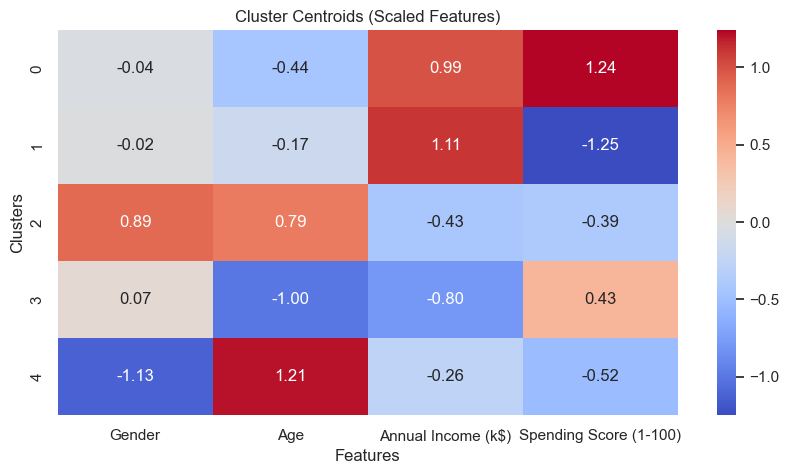

In [91]:
plt.figure(figsize=(10,5))

sns.heatmap(
    centroids,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Cluster Centroids (Scaled Features)")

plt.xlabel("Features")

plt.ylabel("Clusters")

plt.show()

Interpretation

Positive values indicate above-average feature values, while negative values indicate below-average values.

Cluster Profiling

Cluster profiling helps understand the characteristics of each customer segment.

In [92]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)

cluster_profile

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,162.000000,0.538462,32.692308,86.538462,82.128205
1,165.482759,0.551724,36.482759,89.517241,18.000000
2,73.651163,1.000000,49.813953,49.232558,40.069767
3,52.814815,0.592593,24.907407,39.722222,61.203704
4,84.685714,0.000000,55.714286,53.685714,36.771429


Cluster Profile Heatmap

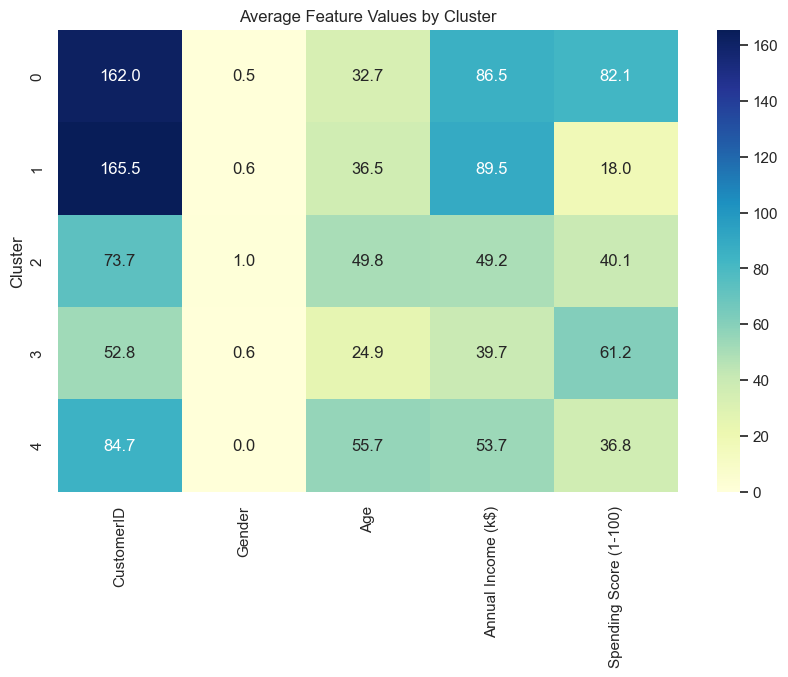

In [93]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f"
)

plt.title("Average Feature Values by Cluster")

plt.show()

Average Age by Cluster

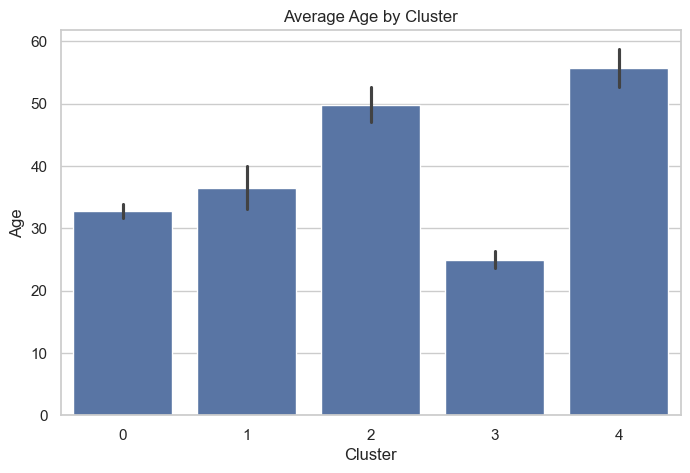

In [94]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Cluster",
    y="Age",
    estimator=np.mean
)

plt.title("Average Age by Cluster")

plt.show()

Average Income by Cluster

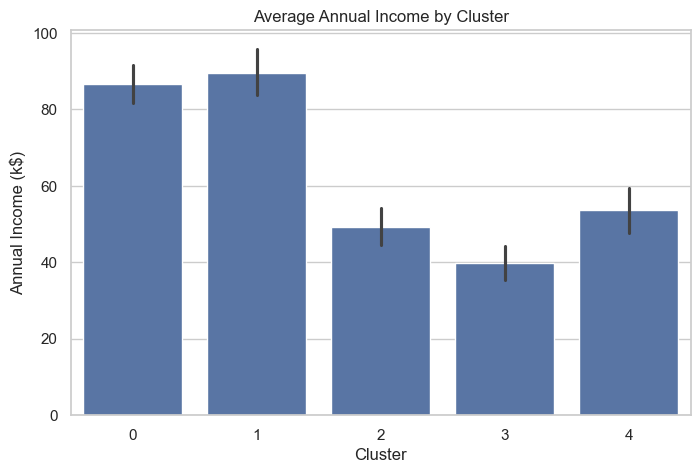

In [95]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Cluster",
    y="Annual Income (k$)",
    estimator=np.mean
)

plt.title("Average Annual Income by Cluster")

plt.show()

Average Spending Score by Cluster

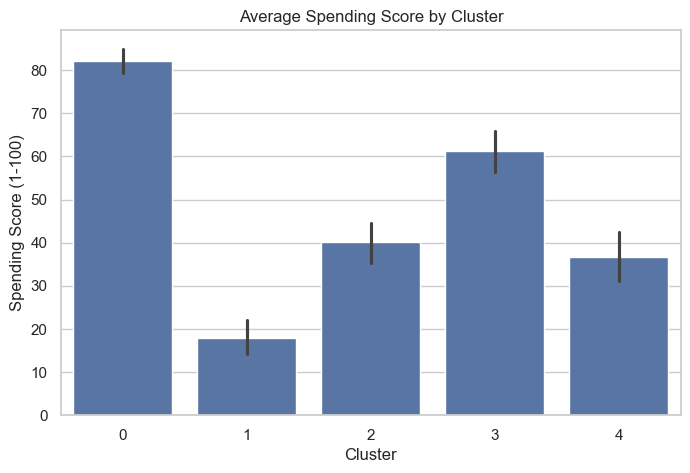

In [96]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Cluster",
    y="Spending Score (1-100)",
    estimator=np.mean
)

plt.title("Average Spending Score by Cluster")

plt.show()

Cluster Distribution Across Gender

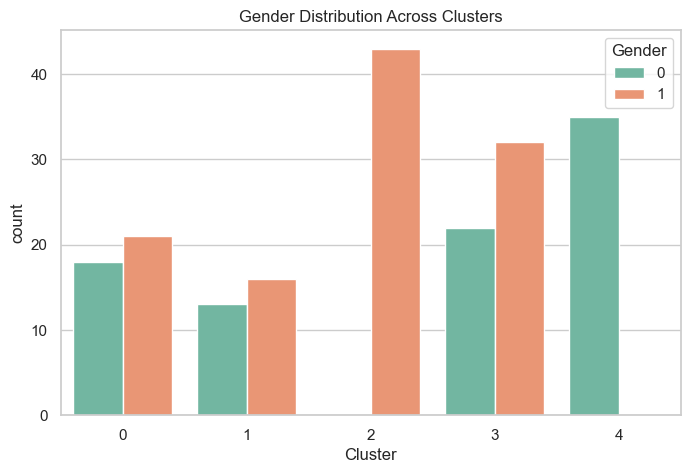

In [97]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Cluster",
    hue="Gender",
    palette="Set2"
)

plt.title("Gender Distribution Across Clusters")

plt.show()

Interpretation

This plot helps determine whether any customer segment is dominated by a particular gender.

Pairplot Colored by Cluster

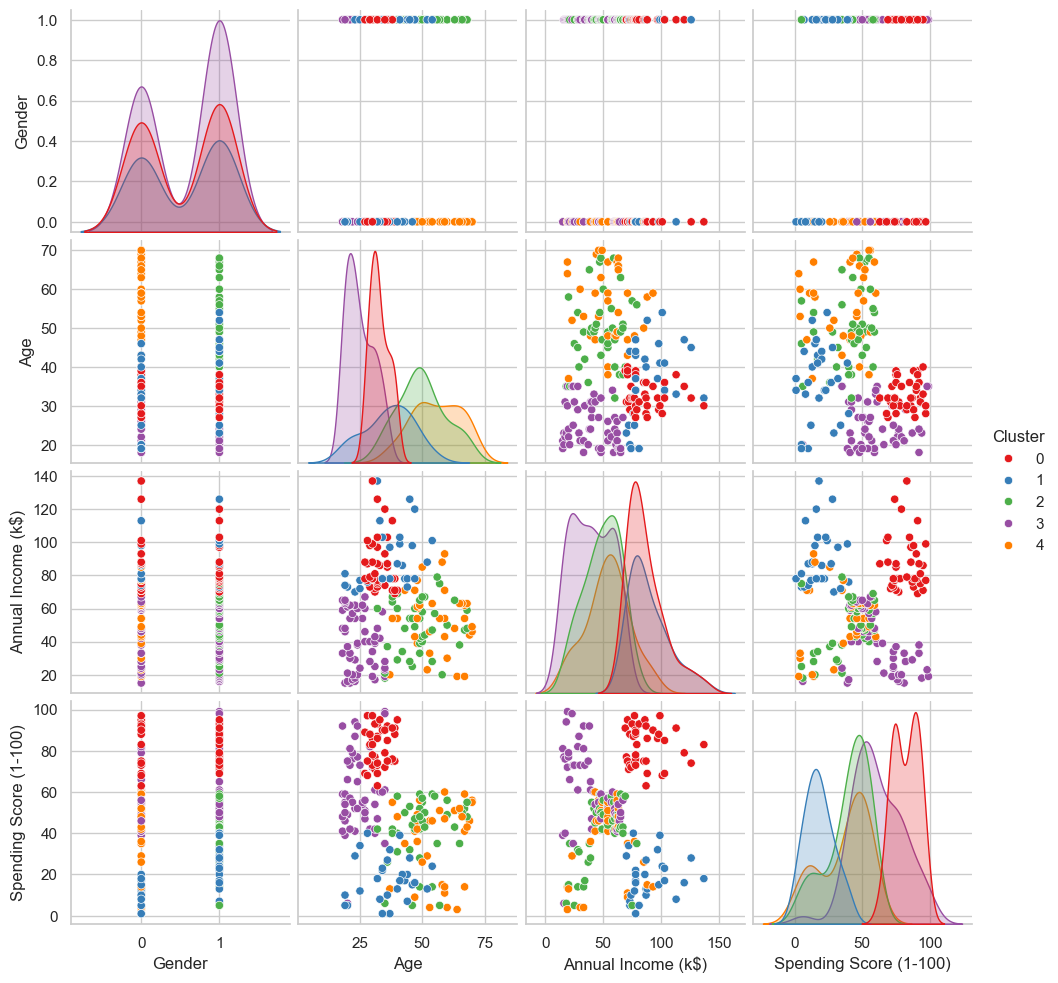

In [98]:
sns.pairplot(
    df.drop("CustomerID", axis=1),
    hue="Cluster",
    palette="Set1",
    diag_kind="kde"
)

plt.show()

how well the clusters separate across different feature combinations.

Violin Plot

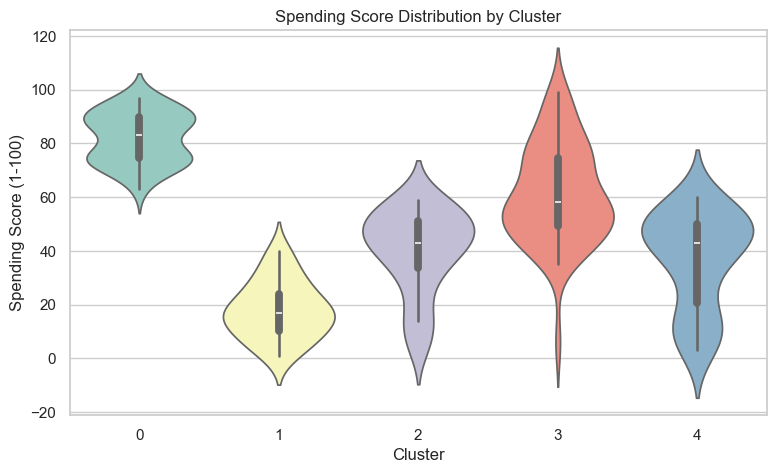

In [99]:
plt.figure(figsize=(9,5))

sns.violinplot(
    data=df,
    x="Cluster",
    y="Spending Score (1-100)",
    palette="Set3"
)

plt.title("Spending Score Distribution by Cluster")

plt.show()

This visualization highlights the spread and density of spending scores within each cluster.

Parallel Coordinates Plot

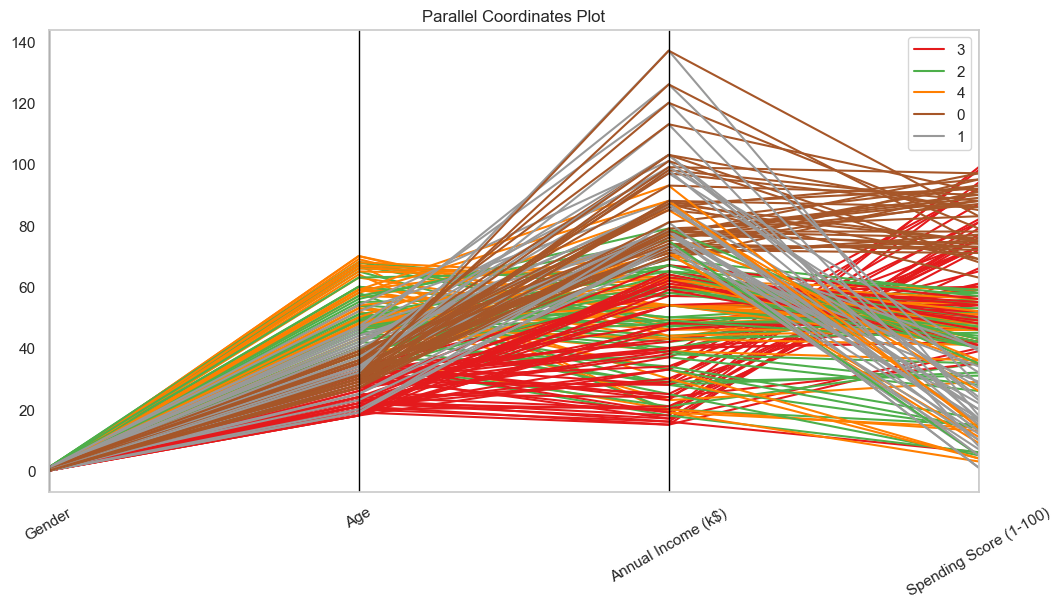

In [100]:
from pandas.plotting import parallel_coordinates

parallel_df = df.drop("CustomerID", axis=1).copy()

parallel_df["Cluster"] = parallel_df["Cluster"].astype(str)

plt.figure(figsize=(12,6))

parallel_coordinates(
    parallel_df,
    "Cluster",
    colormap="Set1"
)

plt.title("Parallel Coordinates Plot")

plt.xticks(rotation=30)

plt.show()

Cluster Evaluation

Unlike supervised learning, K-Means does not have accuracy, precision, recall, or F1-score because there are no true labels.
Instead, we use internal clustering evaluation metrics.

Silhouette Score

The Silhouette Score measures how similar a data point is to its own cluster compared to other clusters.

Range: -1 to +1
Closer to 1 → Better clustering
Around 0 → Overlapping clusters
Less than 0 → Poor clustering

In [101]:
sil_score = silhouette_score(
    X_scaled,
    clusters
)

print(f"Silhouette Score : {sil_score:.3f}")

Silhouette Score : 0.304


Calinski-Harabasz Index

Higher values indicate more distinct and compact clusters.

In [102]:
ch_score = calinski_harabasz_score(
    X_scaled,
    clusters
)

print(f"Calinski-Harabasz Score : {ch_score:.2f}")

Calinski-Harabasz Score : 68.96


Davies-Bouldin Index

Lower values indicate better clustering.

In [103]:
db_score = davies_bouldin_score(
    X_scaled,
    clusters
)

print(f"Davies-Bouldin Score : {db_score:.3f}")

Davies-Bouldin Score : 1.167


Display All Metrics Together

In [104]:
evaluation = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Calinski-Harabasz",
        "Davies-Bouldin"
    ],
    "Score": [
        sil_score,
        ch_score,
        db_score
    ]
})

evaluation

,Metric,Score
0,Silhouette Score,0.304060
1,Calinski-Harabasz,68.964568
2,Davies-Bouldin,1.167230


Visualize Evaluation Metrics

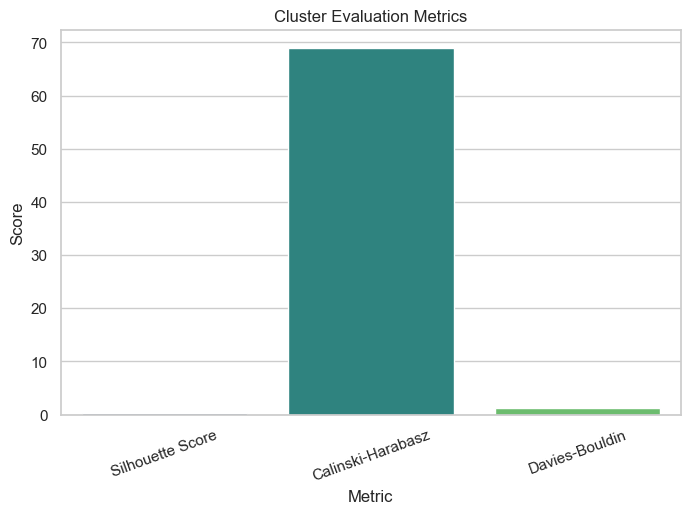

In [105]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=evaluation,
    x="Metric",
    y="Score",
    palette="viridis"
)

plt.title("Cluster Evaluation Metrics")

plt.xticks(rotation=20)

plt.show()

Predicting the Cluster for a New Customer

Create New Customer

In [106]:
new_customer = pd.DataFrame({
    "Gender": [1],          # Female
    "Age": [29],
    "Annual Income (k$)": [65],
    "Spending Score (1-100)": [70]
})

Scale the Features

In [107]:
new_scaled = scaler.transform(new_customer)

Predict Cluster

In [108]:
predicted_cluster = kmeans.predict(new_scaled)

print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 3


Save the Model

In [109]:
joblib.dump(
    kmeans,
    "kmeans_customer_segmentation.pkl"
)

['kmeans_customer_segmentation.pkl']

In [110]:
joblib.dump(
    scaler,
    "customer_scaler.pkl"
)

['customer_scaler.pkl']

In [111]:
loaded_model = joblib.load(
    "kmeans_customer_segmentation.pkl"
)

loaded_scaler = joblib.load(
    "customer_scaler.pkl"
)

In [112]:
prediction = loaded_model.predict(
    loaded_scaler.transform(new_customer)
)

print(prediction)

[3]


Business Insights

After examining the cluster profiles, each cluster can be interpreted for business decision-making.

Cluster 0 – Budget Customers
Low annual income
Low spending score
Focus on discounts and value-based promotions.

Cluster 1 – Premium Customers
High income
High spending
Offer loyalty programs and exclusive memberships.

Cluster 2 – Careful Spenders
High income
Low spending
Encourage purchases with personalized offers and premium bundles.

Cluster 3 – Young Active Shoppers
Younger customers
Moderate income
High spending
Recommend trending products and digital marketing campaigns.

Cluster 4 – Average Customers
Average income
Average spending
Maintain engagement through seasonal promotions and personalized recommendations.